## Overview

The goal of this project is to use and compare different Machine Learning models and to make predicrtions based on selected features. The student data for Portuguese schools was used for this project with a potential result of identifying students who may need additional assistance and interventions to improve their grades.

**Task 1.** Clean and explore the data.

**Task 2.** Create a regression model to predict student's grade.

**Task 3.** Evaluate a model performance using appropriate metrics to assess its accuracy and effectiveness.


In [1]:
import numpy as np
import pandas as pd
data = pd.read_csv('../data/student-mat.csv')

In [2]:
#data.info()
#data.head(10)
target = data.loc[:,'G3']
features = data.drop('G3',axis=1)
features.guardian.value_counts()
# NA: age, absences_G1, G2 G3

guardian
mother    273
father     90
other      32
Name: count, dtype: int64

In [3]:
features.loc[features.reason == 'reputation',['school','reason']]
data.groupby('address')['G3'].mean()
data.absences_G1.value_counts()

absences_G1
0.0     242
1.0      80
2.0      36
3.0      14
4.0       4
9.0       2
6.0       2
12.0      1
5.0       1
Name: count, dtype: int64

In [4]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(features,target,test_size = 0.2,random_state = 42)

In [5]:
data.loc[data.absences_G3.isna(),:]
data.loc[data.G3 == 0,:]

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,goout,Dalc,Walc,health,absences_G1,absences_G2,absences_G3,G1,G2,G3
128,GP,M,NaN,R,GT3,T,2,2,services,other,...,3,1,2,4,0.0,0.0,0.0,7,4,0
130,GP,F,15.0,R,GT3,T,3,4,services,teacher,...,2,2,2,5,0.0,0.0,0.0,12,0,0
131,GP,F,15.0,U,GT3,T,1,1,at_home,other,...,3,1,2,4,0.0,1.0,0.0,8,0,0
134,GP,M,15.0,R,GT3,T,3,4,at_home,teacher,...,3,1,1,5,0.0,1.0,0.0,9,0,0
135,GP,F,15.0,U,GT3,T,4,4,services,at_home,...,3,1,1,5,0.0,1.0,0.0,11,0,0
136,GP,M,17.0,R,GT3,T,3,4,at_home,other,...,5,2,4,5,0.0,0.0,0.0,10,0,0
137,GP,F,16.0,U,GT3,A,3,3,other,other,...,2,1,1,5,0.0,1.0,0.0,4,0,0
140,GP,M,15.0,U,GT3,T,4,3,teacher,services,...,2,1,1,3,0.0,2.0,0.0,7,9,0
144,GP,M,17.0,U,GT3,T,2,1,other,other,...,5,1,2,5,0.0,0.0,0.0,5,0,0
146,GP,F,15.0,U,GT3,T,3,2,health,services,...,2,1,1,3,0.0,0.0,0.0,6,7,0


In [6]:
#data.describe()
#data.info()
data.age.value_counts(normalize = True)

age
16.0    0.258486
17.0    0.253264
15.0    0.208877
18.0    0.203655
19.0    0.062663
20.0    0.007833
22.0    0.002611
21.0    0.002611
Name: proportion, dtype: float64

In [7]:
import matplotlib.pyplot as plt 
import seaborn as sns
plt.rc('axes', labelsize=15, titlesize=16)
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)

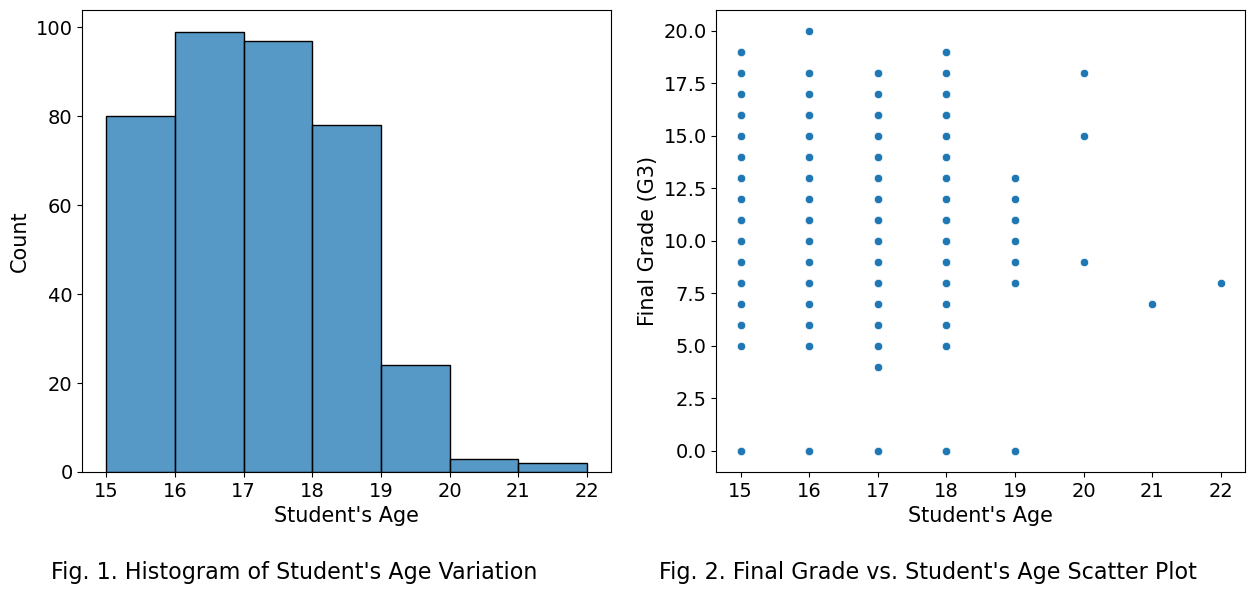

In [8]:
fig, axes = plt.subplots(1,2,figsize = (15,6))
#data.iloc[:,20:]
#data.info()
sns.histplot(data = data, x='age',binwidth = 1,ax = axes[0])
axes[0].set(xlabel = "Student's Age", ylabel ='Count')
axes[0].set_title("Fig. 1. Histogram of Student's Age Variation",y=-0.25,x=0.4)
sns.scatterplot(data =data,x = 'age',y = 'G3',ax = axes[1])
axes[1].set(xlabel = "Student's Age",ylabel ='Final Grade (G3)')
axes[1].set_title("Fig. 2. Final Grade vs. Student's Age Scatter Plot",y=-0.25,x=0.4)
plt.savefig('age')
plt.show()

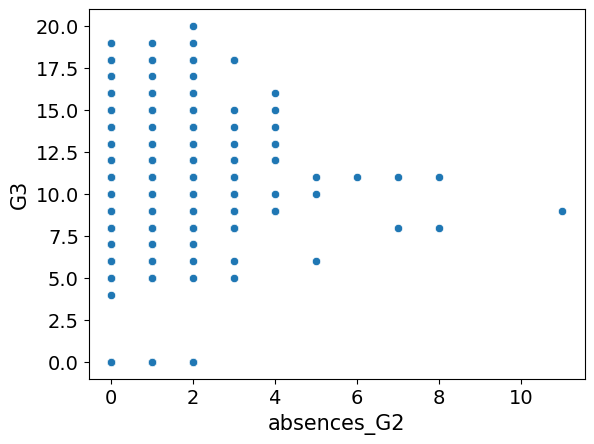

In [9]:
sns.scatterplot(data = data, x = 'absences_G2',y = 'G3')
plt.show()

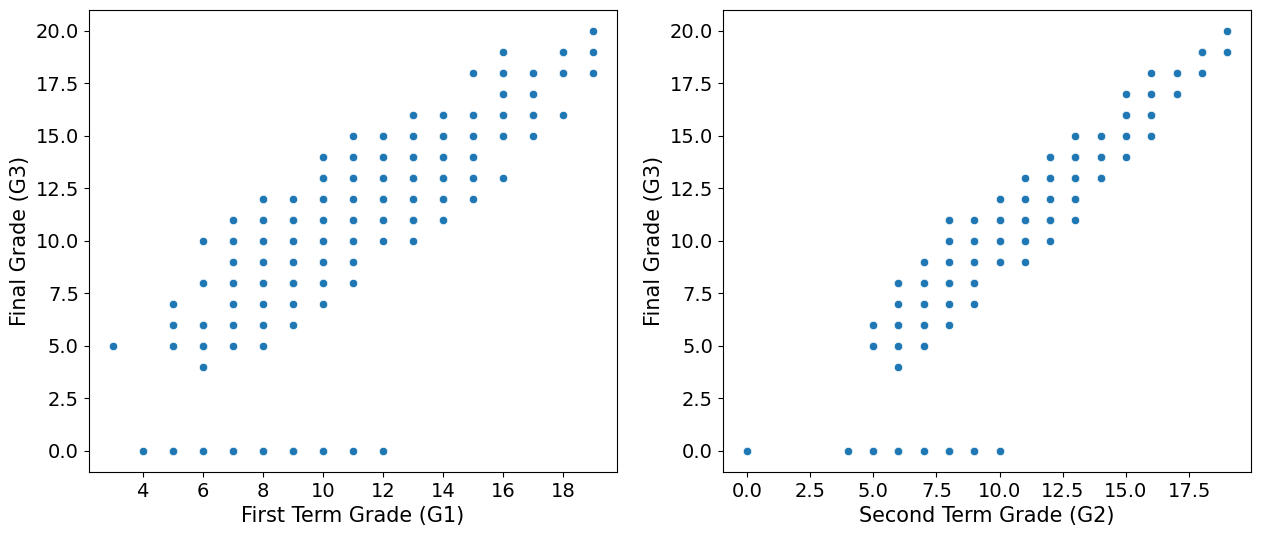

In [10]:
fig, axes = plt.subplots(1,2,figsize = (15,6))
sns.scatterplot(data = data, x = 'G1',y = 'G3',ax=axes[0])
axes[0].set(xlabel = 'First Term Grade (G1)',ylabel = 'Final Grade (G3)')
sns.scatterplot(data = data, x = 'G2',y = 'G3',ax=axes[1])
axes[1].set(xlabel = 'Second Term Grade (G2)',ylabel = 'Final Grade (G3)')
#sns.scatterplot(data = data, x = 'G2',y = 'G3')
plt.savefig('scatterplot')
plt.show()

In [11]:
#data.loc[data.G3 == 0]
data_num = data[['age','failures','absences_G1','absences_G2','absences_G3','G1','G2','G3']]
data_cat = data.drop(['age','absences_G1','absences_G2','absences_G3','G1','G2','G3'],axis=1)
data_num.corr()



,age,failures,absences_G1,absences_G2,absences_G3,G1,G2,G3
age,1.000000,0.245332,0.156872,0.129578,0.194446,-0.063642,-0.134184,-0.152762
failures,0.245332,1.000000,0.047879,0.084028,0.042807,-0.354718,-0.355896,-0.360415
absences_G1,0.156872,0.047879,1.000000,0.666480,0.902445,-0.030857,-0.038391,0.008686
absences_G2,0.129578,0.084028,0.666480,1.000000,0.603933,0.019292,0.022367,0.041598
absences_G3,0.194446,0.042807,0.902445,0.603933,1.000000,0.006260,0.011550,0.086384
G1,-0.063642,-0.354718,-0.030857,0.019292,0.006260,1.000000,0.852118,0.801468
G2,-0.134184,-0.355896,-0.038391,0.022367,0.011550,0.852118,1.000000,0.904868
G3,-0.152762,-0.360415,0.008686,0.041598,0.086384,0.801468,0.904868,1.000000


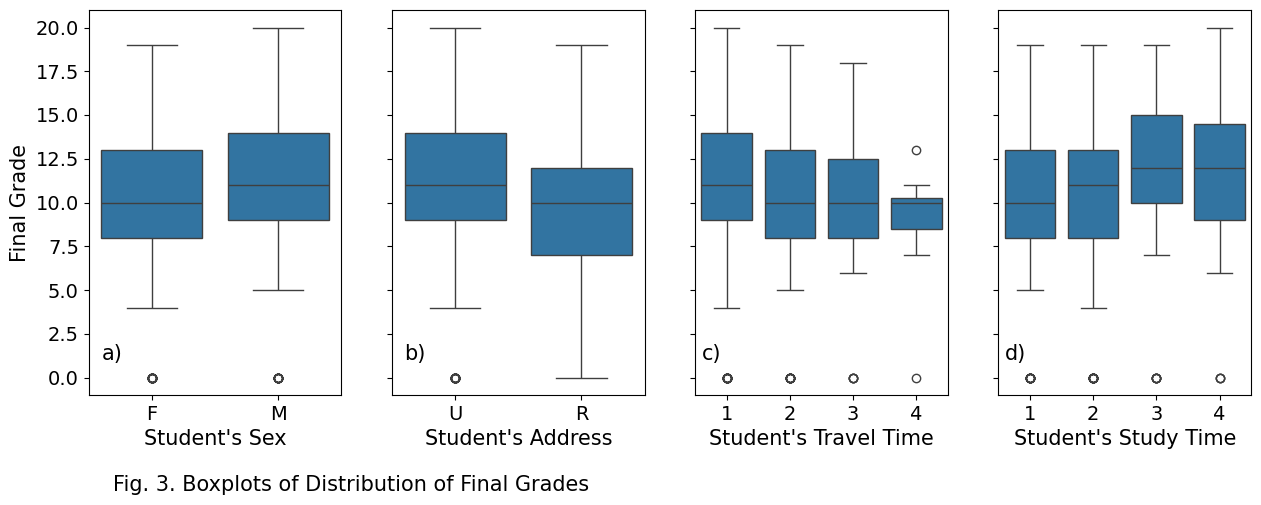

In [12]:
fig, axes = plt.subplots(1,4,figsize = (15,5))
sns.boxplot(x = 'sex',y = 'G3', data =data,ax = axes[0])
axes[0].set(xlabel = "Student's Sex", ylabel ='Final Grade')
axes[0].annotate('a)',xy = (-0.4,1),size=15)

sns.boxplot(x = 'address',y = 'G3', data =data, ax = axes[1])
axes[1].set(xlabel = "Student's Address", ylabel ='')
axes[1].tick_params(labelleft = False)
axes[1].annotate('b)',xy = (-0.4,1),size=15)

sns.boxplot(x = 'traveltime',y = 'G3', data =data, ax = axes[2])
axes[2].set(xlabel = "Student's Travel Time", ylabel ='')
axes[2].tick_params(labelleft = False)
axes[2].annotate('c)',xy = (-0.4,1),size=15)

sns.boxplot(x = 'studytime',y = 'G3', data =data, ax = axes[3])
axes[3].set(xlabel = "Student's Study Time", ylabel ='')
axes[3].tick_params(labelleft = False)
axes[3].annotate('d)',xy = (-0.4,1),size=15)

fig.suptitle("Fig. 3. Boxplots of Distribution of Final Grades",y=-0.05,x=0.3,size = 15)

plt.savefig('boxplots1')
plt.show()

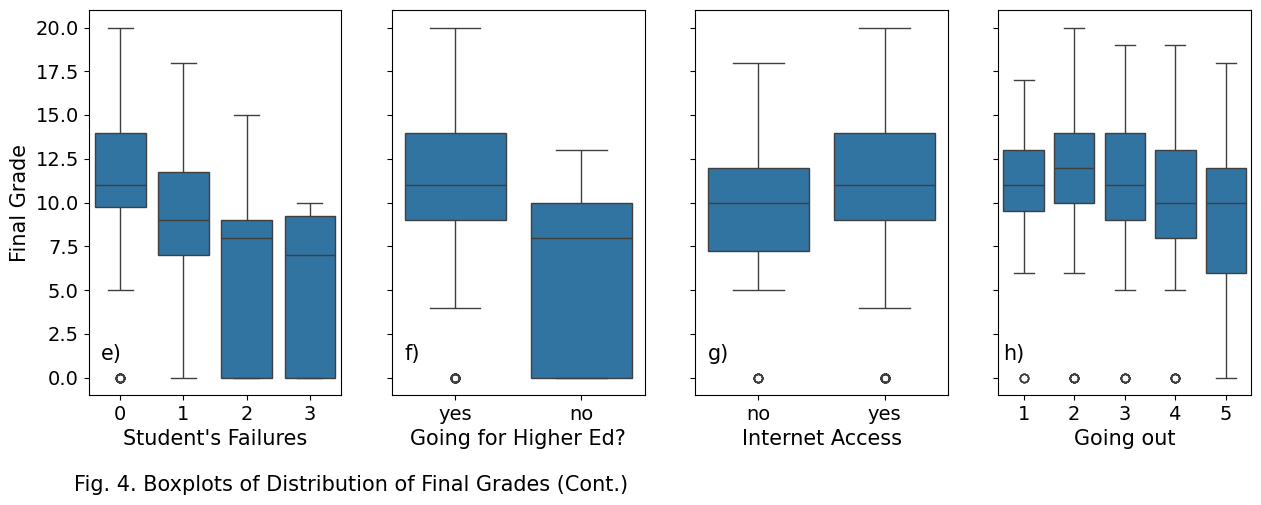

In [13]:
fig, axes = plt.subplots(1,4,figsize = (15,5))
sns.boxplot(x = 'failures',y = 'G3', data =data, ax = axes[0])
axes[0].set(xlabel = "Student's Failures", ylabel ='Final Grade')
#axes[4].tick_params(labelleft = False)
axes[0].annotate('e)',xy = (-0.3,1),size=15)

sns.boxplot(x = 'higher',y = 'G3', data =data, ax = axes[1])
axes[1].set(xlabel = "Going for Higher Ed?", ylabel ='')
axes[1].tick_params(labelleft = False)
axes[1].annotate('f)',xy = (-0.4,1),size=15)

sns.boxplot(x = 'internet',y = 'G3', data =data, ax = axes[2])
axes[2].set(xlabel = "Internet Access", ylabel ='')
axes[2].tick_params(labelleft = False)
axes[2].annotate('g)',xy = (-0.4,1),size=15)

sns.boxplot(x = 'goout',y = 'G3', data =data, ax = axes[3])
axes[3].set(xlabel = "Going out", ylabel ='')
axes[3].tick_params(labelleft = False)
axes[3].annotate('h)',xy = (-0.4,1),size=15)

fig.suptitle("Fig. 4. Boxplots of Distribution of Final Grades (Cont.)",y=-0.05,x=0.3,size=15)

plt.savefig('boxplots2')
plt.show()

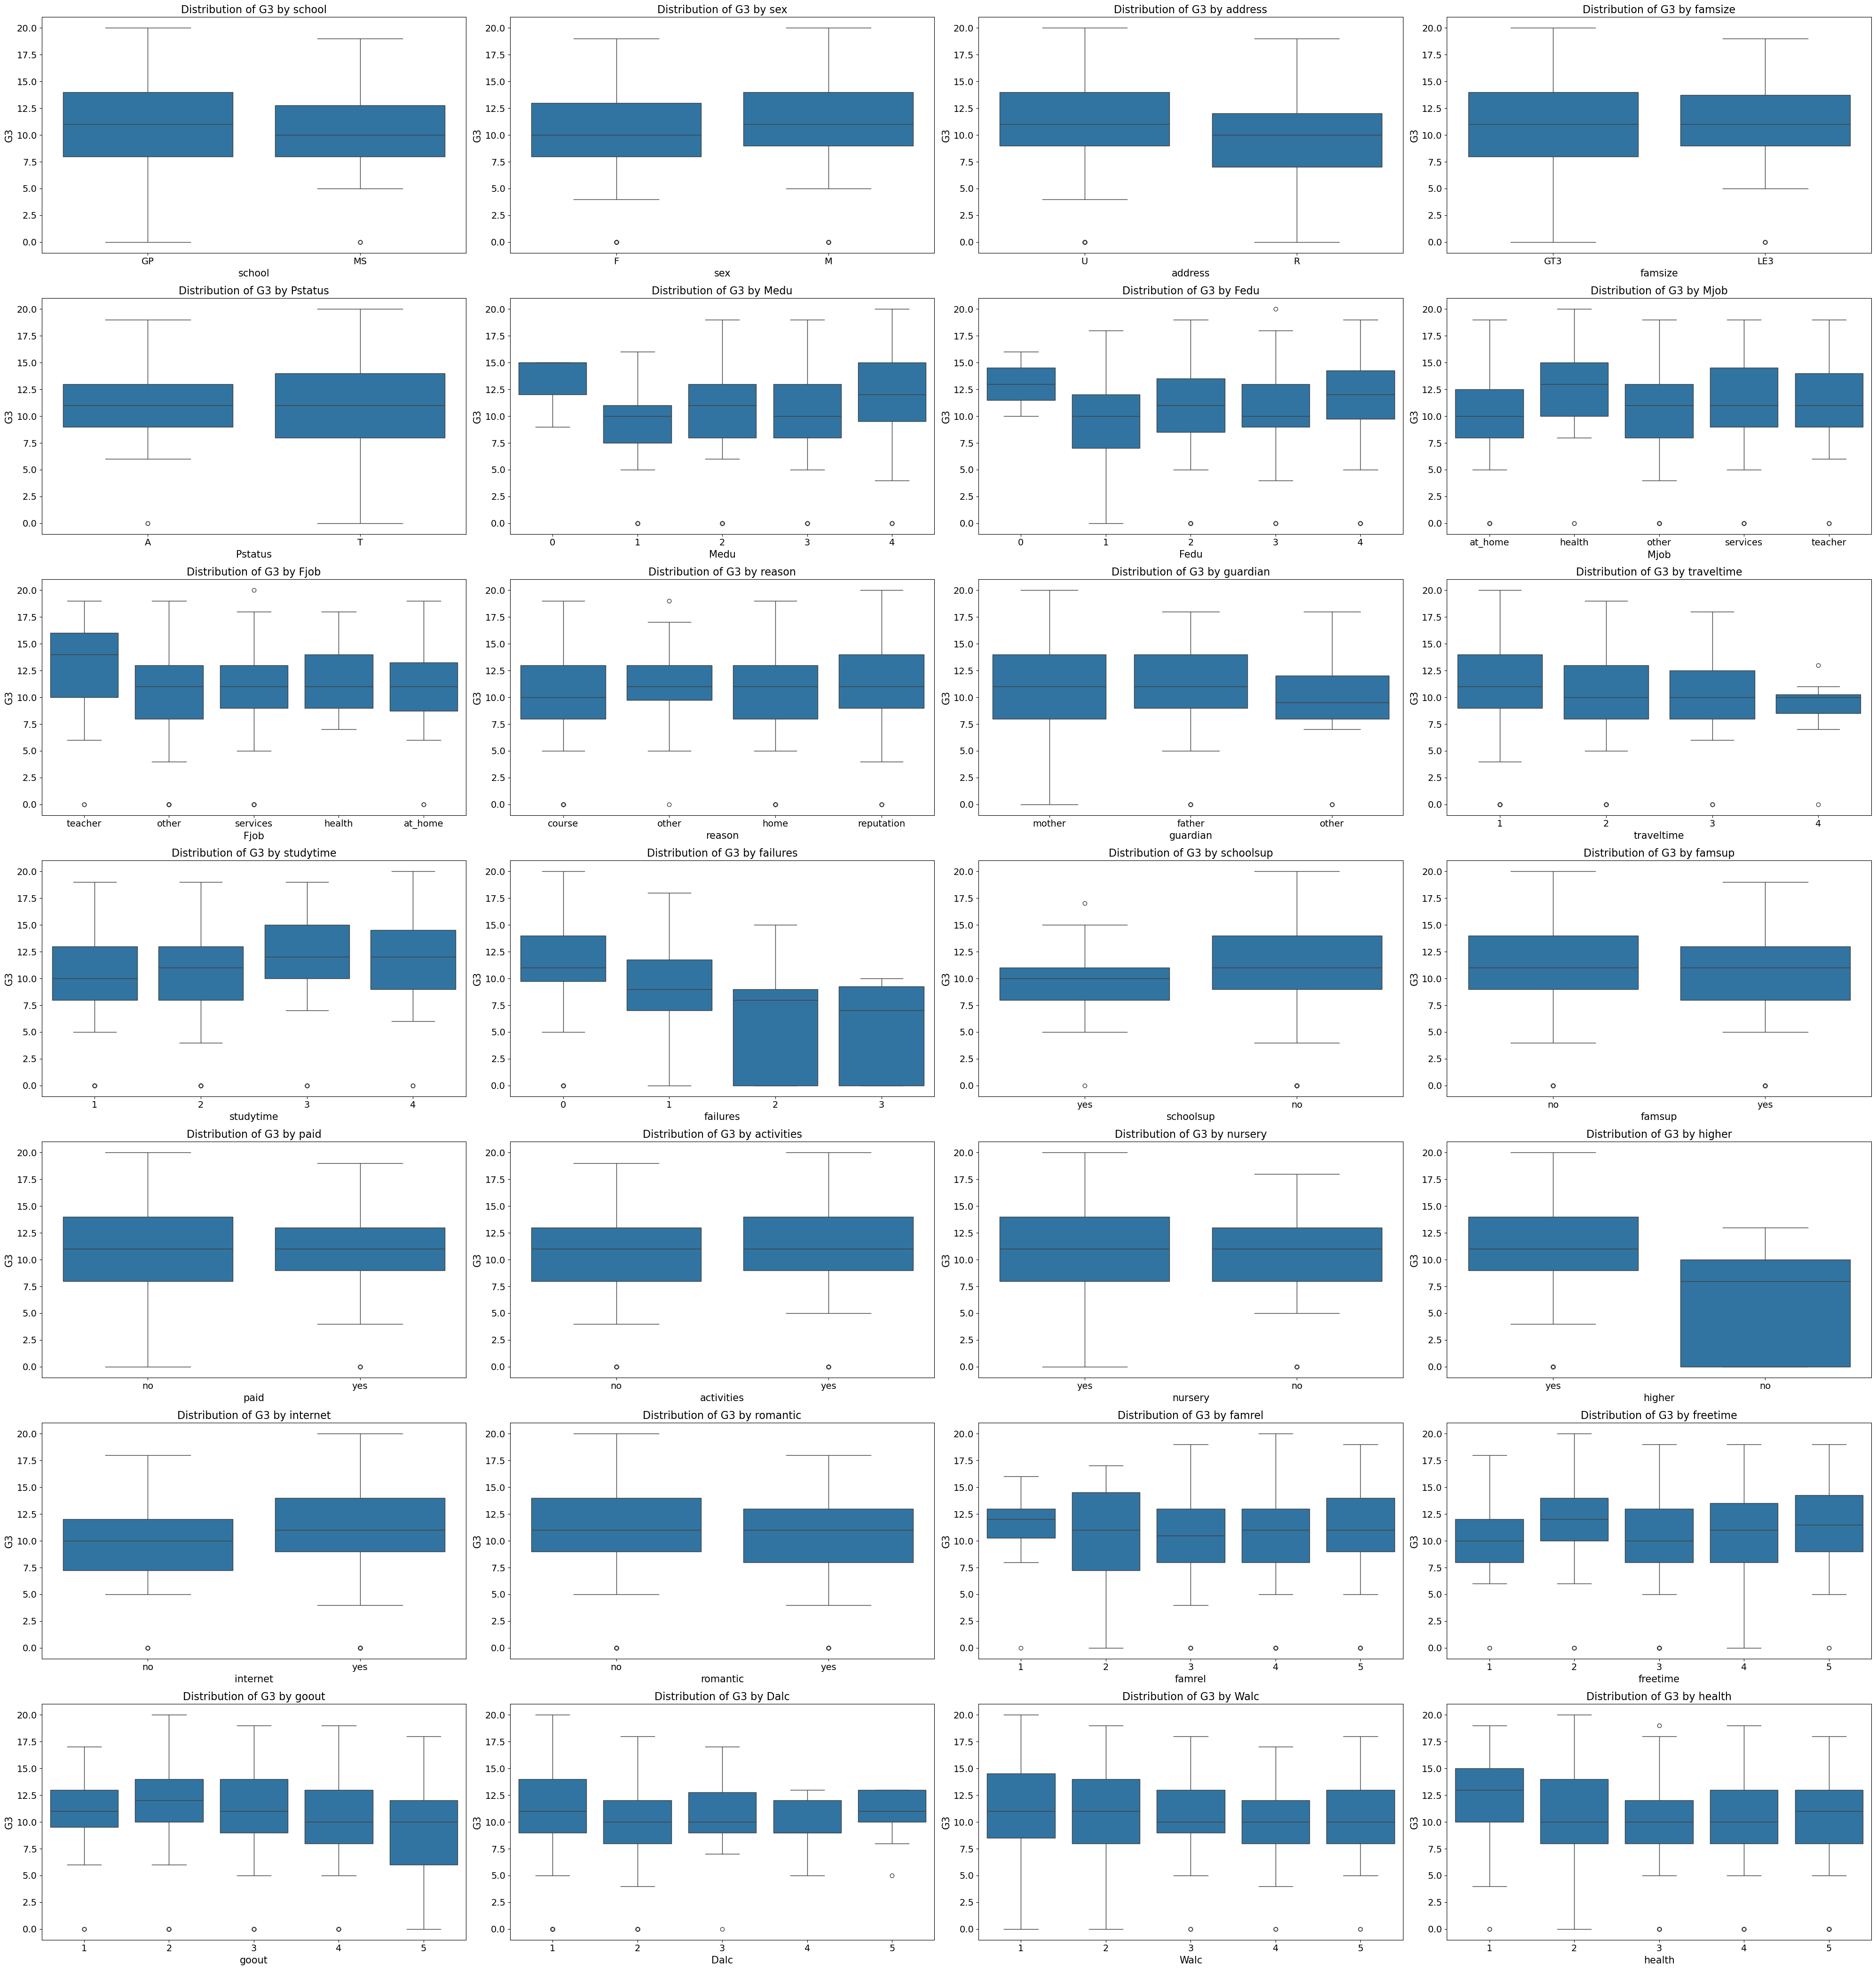

In [14]:
categorical_cols = data_cat.columns
numerical_col = 'G3'

# Determine grid size for subplots
num_categorical = len(categorical_cols)
n_cols = 4  # Adjust as needed
n_rows = (num_categorical + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10 * n_cols, 6 * n_rows))
axes = axes.flatten() # Flatten the axes array for easy iteration

# Create box plots for each categorical variable
for i, col in enumerate(categorical_cols):
    sns.boxplot(x=col, y=numerical_col, data=data, ax=axes[i])
    axes[i].set_title(f'Distribution of {numerical_col} by {col}')

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [15]:
data.loc[data.G3 == 0]
data.failures.value_counts().sort_index()


failures
0    312
1     50
2     17
3     16
Name: count, dtype: int64

In [16]:
data.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences_G1', 'absences_G2', 'absences_G3', 'G1',
       'G2', 'G3'],
      dtype='object')


### Feature Selection


In [17]:
numeric_columns = ['age','failures','absences_G1','absences_G2','absences_G3','G1','G2']
categorical_columns = ['sex','higher','internet']
ordinal_columns = ['traveltime','studytime','goout']

In [18]:
data[categorical_columns]

,sex,higher,internet
0,F,yes,no
1,F,yes,yes
2,F,yes,yes
3,F,yes,yes
4,F,yes,no
...,...,...,...
390,M,yes,no
391,M,yes,yes
392,M,yes,no
393,M,yes,yes


### Custom Transformer

G3 is the final year grade and is highly correlated with G2 and G1, which are grades from the first two terms. Predicting G3 without using G2 and G1 is more challenging but also more valuable since you could make predictions earlier in the year. Therefore, we will create separate models (one that includes the G1 and G2 columns and one that excludes them) to test this.

A new column called `absences_sum`  sums the `absences_G1`, `absences_G2`, and `absences_G3` columns.
The `G1` and `G2` columns are dropped if the parameter `drop_grades` is `True` and kept if `drop_grades` is `False`.


In [19]:
from sklearn.base import BaseEstimator, TransformerMixin

class ProjectTransformer(BaseEstimator,TransformerMixin):
    def __init__(self,drop_grades = True):
        self.drop_grades = drop_grades

    def fit(self,X,y=None):
        return self

    def transform(self,X):
        X['absences_sum'] = X['absences_G1'] + X['absences_G2'] + X['absences_G3']
        X = X.drop(['absences_G1','absences_G2','absences_G3'],axis=1)
        if self.drop_grades:
            X.drop(['G1','G2'],axis=1, inplace = True)
            return X
        else:
            return X
        

In [506]:
#data.drop(['absences_G1','absences_G2','absences_G3'],axis=1,inplace = True)


### Data Pipelines
Transform  dataset into two sets of transformed data: one with the G1/G2 columns and one without them.


In [21]:
# Pipelines for numerical variables
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

numeric_pipeline_with_grades = make_pipeline(SimpleImputer(strategy = 'median').set_output(transform = 'pandas'),
                                             ProjectTransformer(drop_grades = False),
                                             StandardScaler())

numeric_pipeline_without_grades = make_pipeline(SimpleImputer(strategy = 'median').set_output(transform = 'pandas'),
                                             ProjectTransformer(drop_grades = True),
                                             StandardScaler())


In [22]:
# Pipelines for categorical and ordinal variables
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
categorical_pipeline = make_pipeline(SimpleImputer(strategy = 'most_frequent'),
                                     OneHotEncoder(drop = 'first'))
ordinal_pipeline = make_pipeline(SimpleImputer(strategy = 'most_frequent'),
                                 OrdinalEncoder())

In [23]:
from sklearn.compose import ColumnTransformer

column_transformer_with_grades = ColumnTransformer([('num',numeric_pipeline_with_grades,numeric_columns),
                                                    ('cat',categorical_pipeline,categorical_columns),
                                                    ('ord',ordinal_pipeline,ordinal_columns)
                                                   ])

column_transformer_without_grades = ColumnTransformer([('num',numeric_pipeline_without_grades,numeric_columns),
                                                    ('cat',categorical_pipeline,categorical_columns),
                                                    ('ord',ordinal_pipeline,ordinal_columns)
                                                   ])

In [24]:
# Transformed features for twi cases, with and without G1, G2 grades
X_train_transformed_with_grades = column_transformer_with_grades.fit_transform(X_train)
X_train_transformed_without_grades = column_transformer_without_grades.fit_transform(X_train)

In [25]:
X_train_transformed_without_grades[0]

array([-0.60476491, -0.45674383, -0.56484386,  1.        ,  1.        ,
        1.        ,  0.        ,  1.        ,  2.        ])

## Models

1) **Initialize Three Regression Models**
- Linear Regression
- Support Vector Machine (SVM) Regression
- Lasso Regression

2) **Compare Models with Cross-Validation**
- Using the above models, perform cross-validation on each model using both sets of transformed data (with and without G1/G2 columns).


In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.linear_model import Lasso
from sklearn.model_selection import cross_val_score

lin_reg = LinearRegression()
#svm_reg = SVR(epsilon = 0.5, dual = 'auto')
svm_reg = SVR()
lasso_reg = Lasso()
#cv_scores_lin_reg_with_grades = cross_val_score(lin_reg,X_train_transformed_with_grades,y_train,cv=3)
#cv_scores_lin_reg_without_grades = cross_val_score(lin_reg,X_train_transformed_without_grades,y_train,cv=3)
#cv_scores_svm_with_grades  = cross_val_score(svm_reg,X_train_transformed_with_grades,y_train, cv=3)
#cv_scores_svm_without_grades = cross_val_score(svm_reg, X_train_transformed_without_grades,y_train,cv=3)
#cv_scores_lasso_with_grades = cross_val_score(lasso_reg,X_train_transformed_with_grades,y_train,cv=3)
#cv_scores_lasso_without_grades = cross_val_score(lasso_reg,X_train_transformed_without_grades,y_train,cv=3)

cv_scores_lin_reg_with_grades = -cross_val_score(lin_reg, X_train_transformed_with_grades, y_train,
                              scoring="neg_root_mean_squared_error", cv=3)
cv_scores_lin_reg_without_grades = -cross_val_score(lin_reg, X_train_transformed_without_grades, y_train,
                              scoring="neg_root_mean_squared_error", cv=3)

cv_scores_svm_with_grades = -cross_val_score(svm_reg, X_train_transformed_with_grades, y_train,
                              scoring="neg_root_mean_squared_error", cv=3)
cv_scores_svm_without_grades = -cross_val_score(svm_reg, X_train_transformed_without_grades, y_train,
                              scoring="neg_root_mean_squared_error", cv=3)

cv_scores_lasso_with_grades = -cross_val_score(lasso_reg, X_train_transformed_with_grades, y_train,
                              scoring="neg_root_mean_squared_error", cv=3)
cv_scores_lasso_without_grades = -cross_val_score(lasso_reg, X_train_transformed_without_grades, y_train,
                              scoring="neg_root_mean_squared_error", cv=3)


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [27]:
#rmse_lin_reg_with_grades = -cross_val_score(lin_reg,X_train_transformed_with_grades,y_train,cv=3,scoring = 'neg_root_mean_squared_error')
#rmse_lin_reg_without_grades = -cross_val_score(lin_reg,X_train_transformed_without_grades,y_train,cv=3,scoring = 'neg_root_mean_squared_error')
#rmse_svm_with_grades = -cross_val_score(svm_reg,X_train_transformed_with_grades,y_train,cv=3,scoring = 'neg_root_mean_squared_error')
#rmse_svm_without_grades = -cross_val_score(svm_reg,X_train_transformed_without_grades,y_train,cv=3,scoring = 'neg_root_mean_squared_error')
#rmse_lasso_with_grades = -cross_val_score(lasso_reg,X_train_transformed_with_grades,y_train,cv=3,scoring = 'neg_root_mean_squared_error')
#rmse_lasso_without_grades = -cross_val_score(lasso_reg,X_train_transformed_without_grades,y_train,cv=3,scoring = 'neg_root_mean_squared_error')

rmse_lin_reg_with_grades = cv_scores_lin_reg_with_grades.mean()
rmse_lin_reg_without_grades = cv_scores_lin_reg_without_grades.mean()
rmse_svm_with_grades = cv_scores_svm_with_grades.mean()
rmse_svm_without_grades = cv_scores_svm_without_grades.mean()
rmse_lasso_with_grades = cv_scores_lasso_with_grades.mean()
rmse_lasso_without_grades = cv_scores_lasso_without_grades.mean()



In [28]:
print(rmse_lin_reg_with_grades)
print(rmse_lin_reg_without_grades)
print(rmse_svm_with_grades)
print(rmse_svm_without_grades)
print(rmse_lasso_with_grades)
print(rmse_lasso_without_grades)


1.8976492146275794
4.318794178048804
2.554882876934234
4.196689143908032
2.169051437265221
4.386455909382055


## Grid Search for SVM Regression


In [30]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C':[0.01,10,100],'epsilon':[0.001,0.1,0.5,1]}
grid_search = GridSearchCV(svm_reg,param_grid,cv=4,verbose=1)
grid_search.fit(X_train_transformed_with_grades,y_train)

best_params_with_grades = grid_search.best_params_
svm_final_grades = grid_search.best_estimator_

print(grid_search.best_score_)

Fitting 4 folds for each of 12 candidates, totalling 48 fits
0.8308934520157688


In [32]:
grid_search.fit(X_train_transformed_without_grades,y_train)
svm_final_nogrades = grid_search.best_estimator_

best_params_without_grades = grid_search.best_params_
print(grid_search.best_score_)


Fitting 4 folds for each of 12 candidates, totalling 48 fits
0.15534328632041544


In [33]:
print(best_params_with_grades)
print(best_params_without_grades)


{'C': 10, 'epsilon': 0.001}
{'C': 10, 'epsilon': 0.5}


## Measure Performance on Test Set


In [34]:
linreg_grades = lin_reg.fit(X_train_transformed_with_grades,y_train)

X_test_transformed_with_grades = column_transformer_with_grades.transform(X_test)
X_test_transformed_without_grades = column_transformer_without_grades.transform(X_test)

predictions_grades = linreg_grades.predict(X_test_transformed_with_grades)
svm_predictions_grades = svm_final_grades.predict(X_test_transformed_with_grades)


In [35]:
from sklearn.metrics import r2_score

linreg_nogrades = lin_reg.fit(X_train_transformed_without_grades,y_train)
linreg_nogrades.coef_
predictions_nogrades = linreg_nogrades.predict(X_test_transformed_without_grades)
svm_predictions_nogrades = svm_final_nogrades.predict(X_test_transformed_without_grades)



In [36]:
# RMSE and R^2 for linear regression models
from sklearn.metrics import root_mean_squared_error

rmse_with_grades = root_mean_squared_error(y_test,predictions_grades)
rmse_without_grades = root_mean_squared_error(y_test,predictions_nogrades)
r2_with_grades = r2_score(y_test,predictions_grades)
r2_without_grades = r2_score(y_test,predictions_nogrades)
print(rmse_with_grades)
print(rmse_without_grades)
print(r2_with_grades)
print(r2_without_grades)

2.184032588766508
4.3177385496054885
0.7673744280403197
0.09081574214251242


In [37]:
# RMSE and R^2 for SVM models
rmse_svm_grades = root_mean_squared_error(y_test,svm_predictions_grades)
rmse_svm_nogrades = root_mean_squared_error(y_test,svm_predictions_nogrades)
r2_svm_grades = r2_score(y_test,svm_predictions_grades)
r2_svm_nogrades = r2_score(y_test,svm_predictions_nogrades)
print(rmse_svm_grades)
print(rmse_svm_nogrades)
print(r2_svm_grades)
print(r2_svm_nogrades)

2.2655759353750313
4.149071238059038
0.7496794690669073
0.16046074347272554
